In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True
cols = sns.color_palette(palette='colorblind', n_colors=3)

We want to load the data from the Schimtt et al. exeriments. The authors provide an excell file where each sheet is the data show in each figure.
This file is `../../../Schmitt_et_al_2022_data/Numerical_Source_data.xlsx`. We parse the data from figure 2 into a new file `../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx` to ease loading via pandas.

Note that the following Fig 2 panels have the noted correspondence:
- 2b - WT ExRai-AMPKAR at the Lysosome 
- 2c - WT ExRai-AMPKAR at the Mitochondria
- 2d - WT ExRai-AMPKAR at the Cytoplasm

Next, we load the sheets as pandas data frames, keeping only the rows and columns with the times, WT mean, and WT STDEV.

In [30]:
# fig 2b - lysosome data
lyso_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2b', skiprows=5, usecols='A:C', names=['Time (min)', 'WT MEAN', 'WT SDEV'])
# fig 2c - mitochondria data
mito_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2c', skiprows=5, usecols='A:C', names=['Time (min)', 'WT MEAN', 'WT SDEV'])
# fig 2e - cytoplasm data
cyto_df = pd.read_excel('../../../Schmitt_et_al_2022_data/Numerical_Source_data_fig_2.xlsx', 
                          sheet_name='Figure 2e', skiprows=5, usecols='A:C', names=['Time (min)', 'WT MEAN', 'WT SDEV'])


Now we want to normalize the data following the advice of Greenwald et al. 2014. First we need to compute the min and max of the entire dataset. Then we compute normalized ratio

$$
R_{\rm norm} = \frac{R - R_{\rm min}}{R_{\rm max} - R_{\rm min}}
$$

In [31]:
upper_lyso = lyso_df['WT MEAN'] + lyso_df['WT SDEV']
lower_lyso = lyso_df['WT MEAN'] - lyso_df['WT SDEV']
upper_mito = mito_df['WT MEAN'] + mito_df['WT SDEV']
lower_mito = mito_df['WT MEAN'] - mito_df['WT SDEV']
upper_cyto = cyto_df['WT MEAN'] + cyto_df['WT SDEV']
lower_cyto = cyto_df['WT MEAN'] - cyto_df['WT SDEV']

global_min = min(lower_lyso.min(), lower_mito.min(), lower_cyto.min())
global_max = max(upper_lyso.max(), upper_mito.max(), upper_cyto.max())

def renormalize(signal, min, max):
    return (signal - min) / (max - min)

ren = lambda signal: renormalize(signal, global_min, global_max)

In [32]:
# cols = ['lightblue', 'grey', 'orange']

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

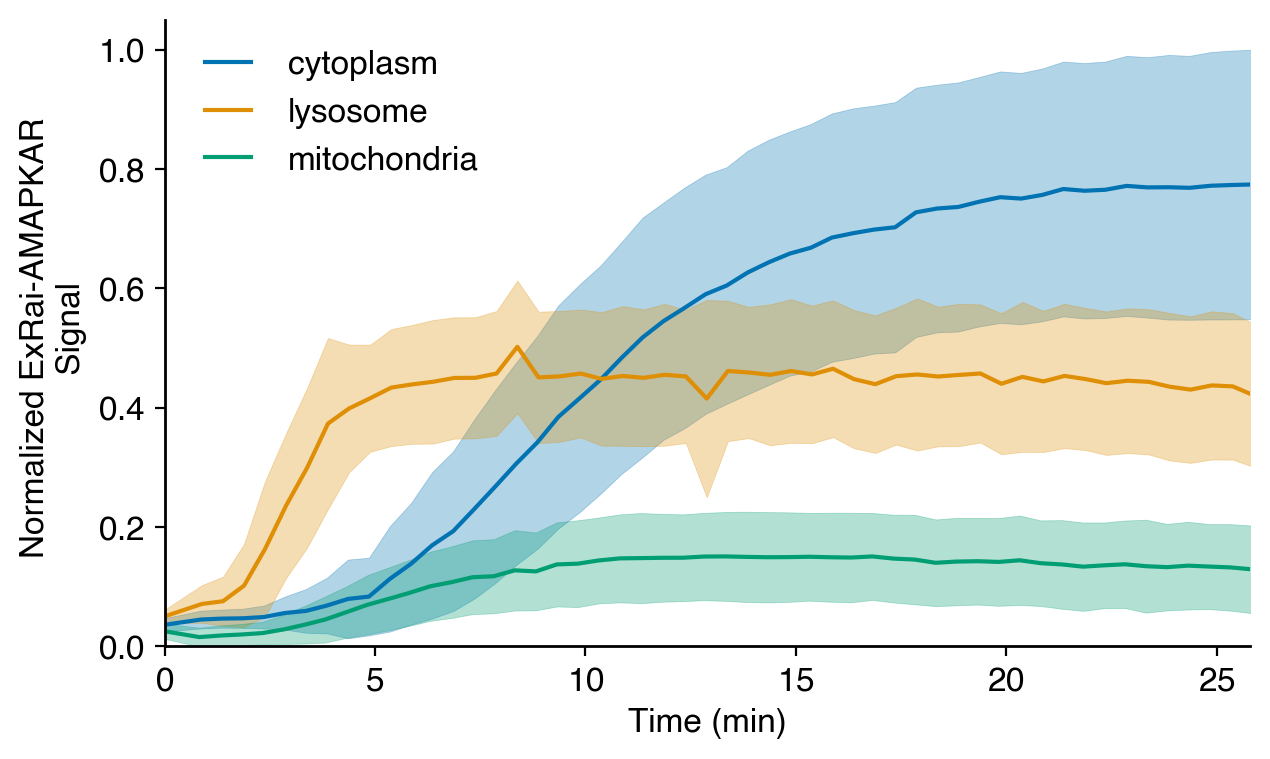

In [35]:
# make a plot
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
# ax[0].plot(lyso_df['Time (min)'], lyso_df['WT MEAN'], label='Lysosome')
# ax[0].fill_between(lyso_df['Time (min)'], upper_lyso, lower_lyso, alpha=0.3)

# ax[0].plot(mito_df['Time (min)'], mito_df['WT MEAN'], label='mitochondria')
# ax[0].fill_between(mito_df['Time (min)'], upper_mito, lower_mito, alpha=0.3)

# ax[0].plot(cyto_df['Time (min)'], cyto_df['WT MEAN'], label='cytoplasm')
# ax[0].fill_between(cyto_df['Time (min)'], upper_cyto, lower_cyto, alpha=0.3)

# ax[0].set_xlabel('Time (min)')
# ax[0].legend(loc='upper left')
# ax[0].set_ylabel('Norm Ratio (Ex480/400)')

ax.plot(cyto_df['Time (min)'], ren(cyto_df['WT MEAN']), label='cytoplasm', color=cols[0])
ax.fill_between(cyto_df['Time (min)'], ren(upper_cyto), ren(lower_cyto), alpha=0.3, color=cols[0])

ax.plot(lyso_df['Time (min)'], ren(lyso_df['WT MEAN']), label='lysosome', color=cols[1])
ax.fill_between(lyso_df['Time (min)'], ren(upper_lyso), ren(lower_lyso), alpha=0.3, color=cols[1])

ax.plot(mito_df['Time (min)'], ren(mito_df['WT MEAN']), label='mitochondria', color=cols[2])
ax.fill_between(mito_df['Time (min)'], ren(upper_mito), ren(lower_mito), alpha=0.3, color=cols[2])
ax.legend(loc='upper left')
ax.set_ylabel('Normalized ExRai-AMAPKAR \n Signal')
ax.set_xlabel('Time (min)')
ax.set_xlim([0.0, 25.8])
ax.set_ylim([0.0, 1.05])
set_size(5,3, ax=ax)
fig.savefig('../../../figures/schmitt_f2_renorm.pdf')

We will assume that the data have constant variance for our statistical model. Thus we want to compute what this value should be. To do so, we take the mean value of the STDEV data

In [58]:
lyso_std = lyso_df['WT SDEV'].mean()
mito_std = mito_df['WT SDEV'].mean()
cyto_std = cyto_df['WT SDEV'].mean()

Renormalize and replot to see what the new data look like

In [59]:
upper_lyso = lyso_df['WT MEAN'] + lyso_std
lower_lyso = lyso_df['WT MEAN'] - lyso_std
upper_mito = mito_df['WT MEAN'] + mito_std
lower_mito = mito_df['WT MEAN'] - mito_std
upper_cyto = cyto_df['WT MEAN'] + cyto_std
lower_cyto = cyto_df['WT MEAN'] - cyto_std

Text(0.5, 0.98, 'Renormalized Data with constant standard deviation')

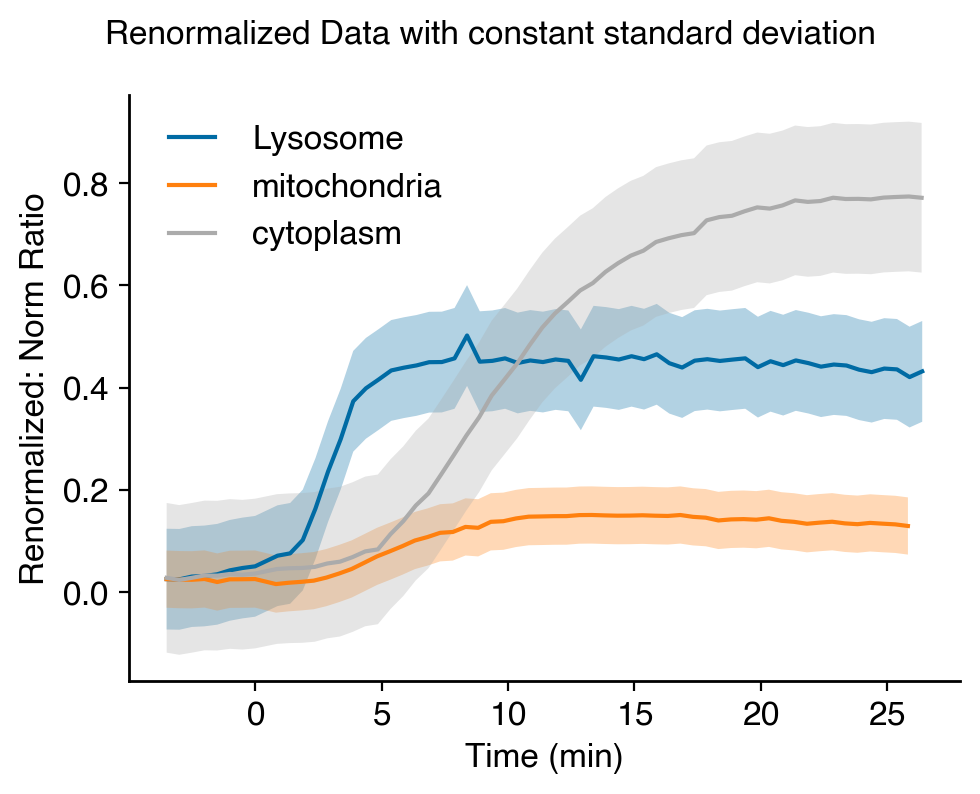

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(lyso_df['Time (min)'], ren(lyso_df['WT MEAN']), label='Lysosome')
ax.fill_between(lyso_df['Time (min)'], ren(upper_lyso), ren(lower_lyso), alpha=0.3)

ax.plot(mito_df['Time (min)'], ren(mito_df['WT MEAN']), label='mitochondria')
ax.fill_between(mito_df['Time (min)'], ren(upper_mito), ren(lower_mito), alpha=0.3)

ax.plot(cyto_df['Time (min)'], ren(cyto_df['WT MEAN']), label='cytoplasm')
ax.fill_between(cyto_df['Time (min)'], ren(upper_cyto), ren(lower_cyto), alpha=0.3)

ax.legend(loc='upper left')
ax.set_ylabel('Renormalized: Norm Ratio')
ax.set_xlabel('Time (min)')
fig.suptitle('Renormalized Data with constant standard deviation')

Now we want to save that data in a way that is convient to load for MCMC sampling

In [61]:
cyto_std_ = cyto_std/ (global_max - global_min)
mito_std_ = mito_std/ (global_max - global_min)
lyso_std_ = lyso_std/ (global_max - global_min)

# cyto_std_ = ren(upper_cyto) - ren(cyto_df['WT MEAN'])
# lyso_std_ = ren(upper_lyso) - ren(lyso_df['WT MEAN'])
# mito_std_ = ren(upper_mito) - ren(mito_df['WT MEAN'])

upper_lyso_ = ren(lyso_df['WT MEAN']) + lyso_std_
lower_lyso_ = ren(lyso_df['WT MEAN']) - lyso_std_
upper_mito_ = ren(mito_df['WT MEAN']) + mito_std_
lower_mito_ = ren(mito_df['WT MEAN']) - mito_std_
upper_cyto_ = ren(cyto_df['WT MEAN']) + cyto_std_
lower_cyto_ = ren(cyto_df['WT MEAN']) - cyto_std_

Text(0.5, 0.98, 'Renormalized Data with constant standard deviation')

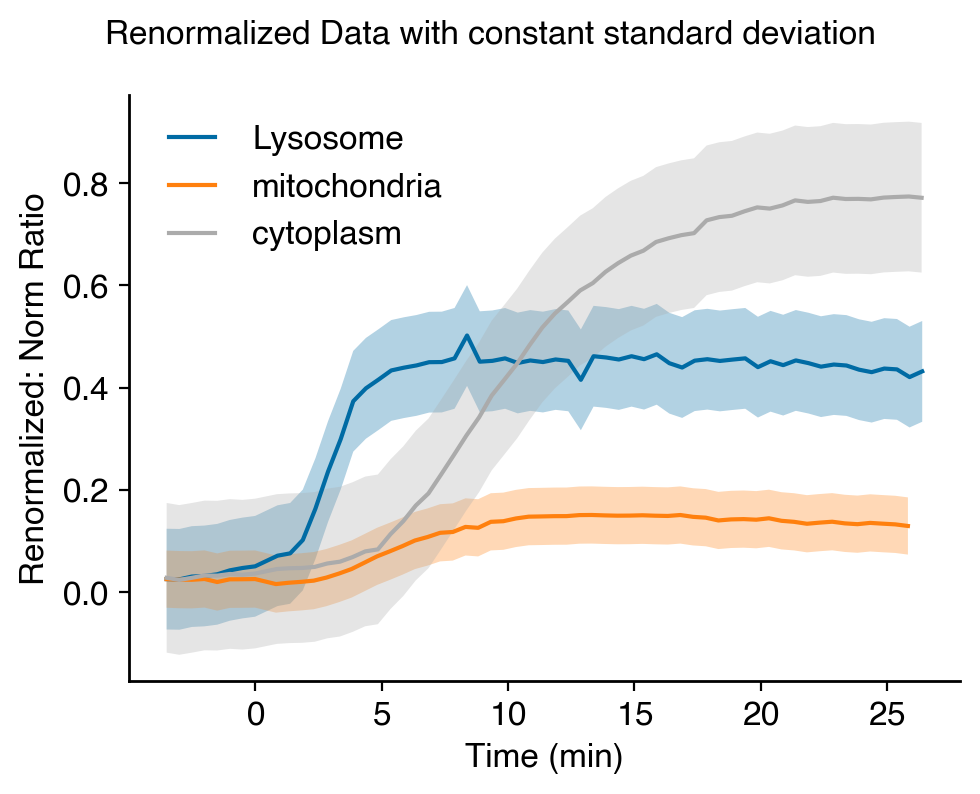

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(lyso_df['Time (min)'], ren(lyso_df['WT MEAN']), label='Lysosome')
ax.fill_between(lyso_df['Time (min)'], upper_lyso_, lower_lyso_, alpha=0.3)

ax.plot(mito_df['Time (min)'], ren(mito_df['WT MEAN']), label='mitochondria')
ax.fill_between(mito_df['Time (min)'], upper_mito_, lower_mito_, alpha=0.3)

ax.plot(cyto_df['Time (min)'], ren(cyto_df['WT MEAN']), label='cytoplasm')
ax.fill_between(cyto_df['Time (min)'], upper_cyto_, lower_cyto_, alpha=0.3)

ax.legend(loc='upper left')
ax.set_ylabel('Renormalized: Norm Ratio')
ax.set_xlabel('Time (min)')
fig.suptitle('Renormalized Data with constant standard deviation')

In [63]:
np.savez('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz', times=lyso_df['Time (min)'].to_numpy(), 
         mean=ren(lyso_df['WT MEAN'].to_numpy()), std=lyso_df['WT SDEV'].to_numpy(), 
         std_constant=lyso_std_)
np.savez('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz', times=mito_df['Time (min)'].to_numpy(), 
         mean=ren(mito_df['WT MEAN'].to_numpy()), std=mito_df['WT SDEV'].to_numpy(), 
         std_constant=mito_std_)
np.savez('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', times=cyto_df['Time (min)'].to_numpy(), 
         mean=ren(cyto_df['WT MEAN'].to_numpy()), std=cyto_df['WT SDEV'].to_numpy(), 
         std_constant=cyto_std_)